# Project Introduction and Required Libraries

This notebook implements the **Smart Ride Fare, Estimated Time and Delay Risk Prediction System** using Machine Learning.

The system performs three tasks:

- **Fare Prediction** using regression
- **Estimated Travel Time Prediction** using regression
- **Delay Risk Prediction** using classification

The implementation intentionally avoids Seaborn, ColumnTransformer, Pipeline, RandomForestRegressor and ROC-AUC/ROC curves.

The required Python libraries are imported below. Only Pandas, NumPy, Matplotlib and basic Scikit-learn components are used.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Load the Kaggle Dataset

The selected Kaggle file is `fairfare_ride_demand_dataset.csv`. Place the CSV file in the same folder as this Jupyter Notebook.

In [3]:
df = pd.read_csv("./Dataset/fairfare_ride_demand_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 29)


# Display the First Records

The first records are displayed to understand the structure and values of the dataset.

In [4]:
df.head(10)

,City,Date,Day_of_Week,Latitude,Longitude,Ride_Distance_KM,Ride_Type,Weather,Event,Payment_Type,Available_Drivers,Demand_Level,Surge_Multiplier,Final_Fare,Hour_of_Day,Is_Weekend,Driver_Performance_Score,Driver_XP,Ride_Priority,Fare_Acceptance,Cancellation_Rate,Time_of_Day,Demand_Score,Driver_Availability,Traffic_Delay,Cancellation_Probability,Driver_Trust_Score,Rider_Trust_Score,Leaderboard_Rank
0,Hyderabad,06-08-2024,1,17.353253,78.466332,6.76,Economy,Cloudy,Festival,UPI,0.940635,0.408931,1.00,92.84,5,0,97.53,554,96.17,0.857885,0.07,Afternoon,80,46,15,0.2,100.0,100,Below Average
1,Mumbai,26-09-2024,3,19.059839,72.858877,3.34,Premium,Stormy,Political Rally,Card,0.236479,0.818456,1.87,149.75,4,0,82.70,967,85.79,0.747193,0.07,Morning Peak,100,86,25,0.3,100.0,50,Below Average
2,Bangalore,27-07-2024,5,12.976855,77.625306,8.86,Luxury,Rainy,Festival,UPI,0.916087,0.837136,1.00,153.18,23,1,95.71,806,94.60,0.868523,0.08,Afternoon,100,32,15,0.3,100.0,100,Below Average
3,Mumbai,23-03-2025,6,19.056439,72.863508,15.95,Luxury,Cloudy,Concert,Cash,0.977525,0.933445,1.00,231.40,15,1,84.63,733,87.14,0.859991,0.07,Evening Peak,95,95,25,0.1,100.0,100,Below Average
4,Chennai,06-08-2024,1,13.110869,80.309381,19.50,Premium,Clear,NaN,Card,0.843581,0.807745,1.00,244.50,12,0,80.59,677,84.91,0.981357,0.05,Evening Peak,65,58,10,0.1,0.0,0,Below Average
5,Delhi,17-10-2024,3,28.712901,77.079418,16.48,Premium,Clear,IPL Match,UPI,0.466766,0.840493,1.56,311.69,17,0,81.38,975,84.57,0.707646,0.08,Afternoon,80,30,15,0.2,100.0,5,Below Average
6,Delhi,21-10-2024,0,28.738914,77.089677,1.93,Luxury,Clear,Concert,Cash,0.697425,0.593713,1.00,54.30,2,0,91.74,662,93.32,0.890320,0.03,Night,80,53,15,0.1,100.0,100,Below Average
7,Delhi,16-02-2025,6,28.656649,77.134974,13.51,Premium,Rainy,Concert,Cash,0.294377,0.990464,2.04,347.00,12,1,86.40,629,88.98,0.801697,0.05,Morning Peak,100,75,25,0.3,100.0,85,Below Average
8,Bangalore,15-01-2025,2,12.957695,77.558570,11.78,Premium,Stormy,NaN,UPI,0.579559,0.920623,1.51,288.62,4,0,96.08,795,94.86,0.800077,0.08,Night,70,67,0,0.5,100.0,0,Below Average
9,Hyderabad,03-08-2024,5,17.381049,78.445229,7.33,Luxury,Clear,Concert,Cash,0.768717,0.960860,1.29,126.38,19,1,85.06,686,89.24,0.841066,0.01,Night,80,46,15,0.2,100.0,100,Below Average


# Check Dataset Dimensions and Column Names

The number of observations and attributes is displayed, followed by all column names.

In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("Column Names:")
for column in df.columns:
    print(column)

Number of Rows: 10000
Number of Columns: 29
Column Names:
City
Date
Day_of_Week
Latitude
Longitude
Ride_Distance_KM
Ride_Type
Weather
Event
Payment_Type
Available_Drivers
Demand_Level
Surge_Multiplier
Final_Fare
Hour_of_Day
Is_Weekend
Driver_Performance_Score
Driver_XP
Ride_Priority
Fare_Acceptance
Cancellation_Rate
Time_of_Day
Demand_Score
Driver_Availability
Traffic_Delay
Cancellation_Probability
Driver_Trust_Score
Rider_Trust_Score
Leaderboard_Rank


# Inspect Dataset Information

The `info()` method shows data types, non-null values and memory information.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   City                      10000 non-null  object 
 1   Date                      10000 non-null  object 
 2   Day_of_Week               10000 non-null  int64  
 3   Latitude                  10000 non-null  float64
 4   Longitude                 10000 non-null  float64
 5   Ride_Distance_KM          10000 non-null  float64
 6   Ride_Type                 10000 non-null  object 
 7   Weather                   10000 non-null  object 
 8   Event                     7980 non-null   object 
 9   Payment_Type              10000 non-null  object 
 10  Available_Drivers         10000 non-null  float64
 11  Demand_Level              10000 non-null  float64
 12  Surge_Multiplier          10000 non-null  float64
 13  Final_Fare                10000 non-null  float64
 14  Hour_of

# Generate Statistical Summary

Descriptive statistics are generated for the numerical variables.

In [7]:
df.describe()

,Day_of_Week,Latitude,Longitude,Ride_Distance_KM,Available_Drivers,Demand_Level,Surge_Multiplier,Final_Fare,Hour_of_Day,Is_Weekend,Driver_Performance_Score,Driver_XP,Ride_Priority,Fare_Acceptance,Cancellation_Rate,Demand_Score,Driver_Availability,Traffic_Delay,Cancellation_Probability,Driver_Trust_Score,Rider_Trust_Score
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,2.986500,18.249686,77.288864,10.259459,0.597589,0.700007,1.266665,186.71914,11.499100,0.284300,90.062354,749.733000,91.55861,0.850222,0.049491,88.457000,65.084600,16.982000,0.224660,95.981170,59.99650
std,2.000629,5.752969,2.433088,5.642591,0.232380,0.174227,0.304772,94.68777,6.903794,0.451103,5.730523,144.793262,4.11115,0.086074,0.029352,13.965445,20.518473,7.790234,0.108899,16.870458,42.09281
min,0.000000,12.921636,72.827845,0.500000,0.200075,0.400019,1.000000,35.50000,0.000000,0.000000,80.010000,500.000000,83.05000,0.700012,0.000000,50.000000,30.000000,0.000000,0.100000,0.000000,0.00000
25%,1.000000,13.058558,77.078833,5.377500,0.393139,0.548971,1.000000,112.01750,5.000000,0.000000,85.197500,624.000000,88.09000,0.775481,0.020000,80.000000,47.000000,15.000000,0.100000,100.000000,10.00000
50%,3.000000,17.383493,77.599286,10.245000,0.599117,0.698127,1.150000,175.86000,12.000000,0.000000,90.050000,751.000000,91.61000,0.850637,0.050000,95.000000,65.000000,15.000000,0.300000,100.000000,75.00000
75%,5.000000,19.102854,78.511893,15.130000,0.800637,0.851901,1.480000,243.29750,17.000000,1.000000,95.052500,875.000000,95.03000,0.924674,0.070000,100.000000,83.000000,25.000000,0.300000,100.000000,100.00000
max,6.000000,28.754027,80.320683,19.990000,0.999884,0.999996,2.200000,615.07000,23.000000,1.000000,100.000000,1000.000000,99.99000,0.999965,0.100000,100.000000,100.000000,25.000000,0.500000,100.000000,100.00000


# Check Missing Values and Their Percentage

Missing values are checked for every column.

The percentage of missing observations in every column is calculated.

In [8]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_summary

Missing Values:
City                           0
Date                           0
Day_of_Week                    0
Latitude                       0
Longitude                      0
Ride_Distance_KM               0
Ride_Type                      0
Weather                        0
Event                       2020
Payment_Type                   0
Available_Drivers              0
Demand_Level                   0
Surge_Multiplier               0
Final_Fare                     0
Hour_of_Day                    0
Is_Weekend                     0
Driver_Performance_Score       0
Driver_XP                      0
Ride_Priority                  0
Fare_Acceptance                0
Cancellation_Rate              0
Time_of_Day                    0
Demand_Score                   0
Driver_Availability            0
Traffic_Delay                  0
Cancellation_Probability       0
Driver_Trust_Score             0
Rider_Trust_Score              0
Leaderboard_Rank               0
dtype: int64


,Missing Values,Missing Percentage
City,0,0.0
Date,0,0.0
Day_of_Week,0,0.0
Latitude,0,0.0
Longitude,0,0.0
Ride_Distance_KM,0,0.0
Ride_Type,0,0.0
Weather,0,0.0
Event,2020,20.2
Payment_Type,0,0.0


# Check Duplicate Records

Duplicate rows are identified before model preparation.

In [9]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


# Remove Duplicate Records

Duplicate records are removed so that repeated observations do not unnecessarily influence the models.

In [10]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (10000, 29)


# Identify Numerical and Categorical Columns

Columns containing numerical values are identified automatically.

Columns containing categorical/text values are identified automatically.

In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

Numerical Columns:
['Day_of_Week', 'Latitude', 'Longitude', 'Ride_Distance_KM', 'Available_Drivers', 'Demand_Level', 'Surge_Multiplier', 'Final_Fare', 'Hour_of_Day', 'Is_Weekend', 'Driver_Performance_Score', 'Driver_XP', 'Ride_Priority', 'Fare_Acceptance', 'Cancellation_Rate', 'Demand_Score', 'Driver_Availability', 'Traffic_Delay', 'Cancellation_Probability', 'Driver_Trust_Score', 'Rider_Trust_Score']
Categorical Columns:
['City', 'Date', 'Ride_Type', 'Weather', 'Event', 'Payment_Type', 'Time_of_Day', 'Leaderboard_Rank']


# Analyze City Distribution

The number of rides recorded for each city is visualized using Matplotlib.

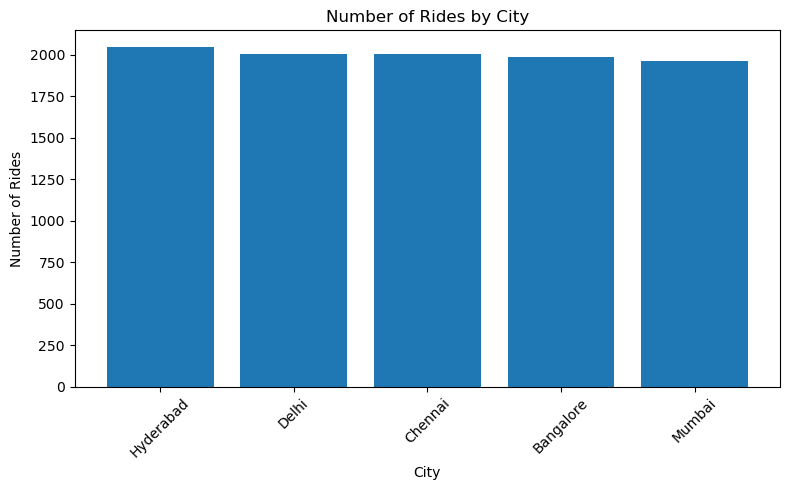

In [12]:
city_counts = df["City"].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(city_counts.index, city_counts.values)

plt.xlabel("City")
plt.ylabel("Number of Rides")
plt.title("Number of Rides by City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analyze Ride Type Distribution

The distribution of ride types is visualized.

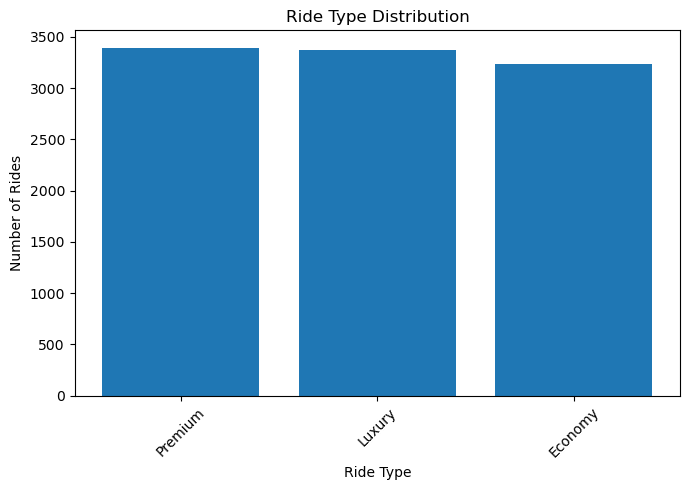

In [13]:
ride_counts = df["Ride_Type"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(ride_counts.index, ride_counts.values)

plt.xlabel("Ride Type")
plt.ylabel("Number of Rides")
plt.title("Ride Type Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analyze Weather Distribution

The distribution of weather conditions is visualized.

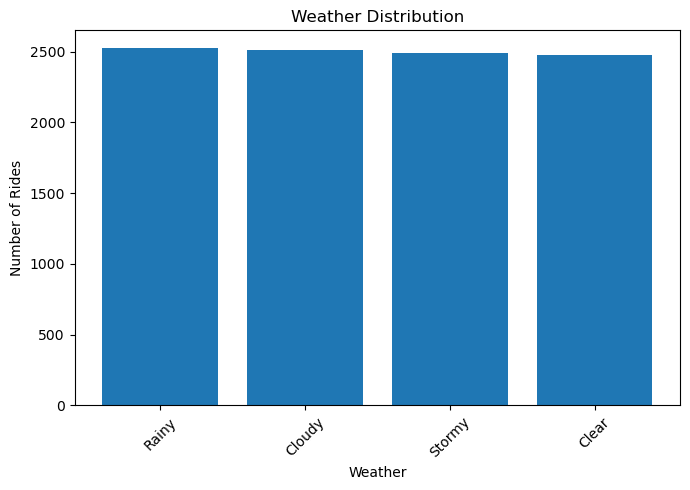

In [14]:
weather_counts = df["Weather"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(weather_counts.index, weather_counts.values)

plt.xlabel("Weather")
plt.ylabel("Number of Rides")
plt.title("Weather Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analyze Final Fare Distribution

The distribution of the final fare is visualized to understand the target variable.

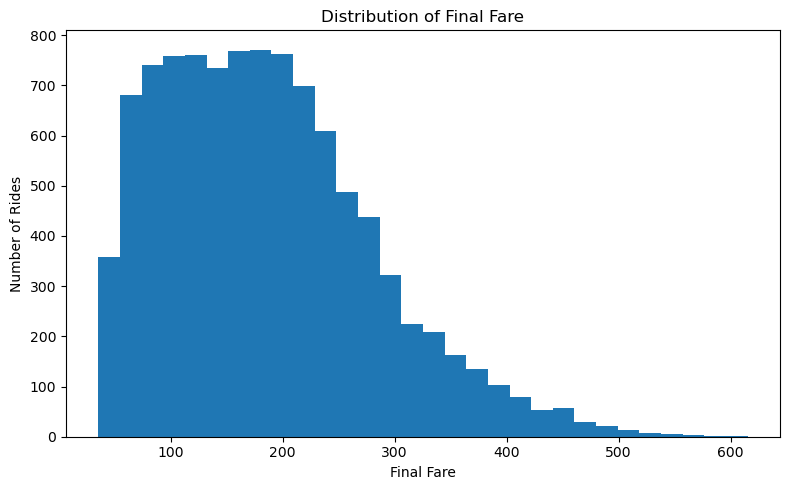

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(df["Final_Fare"], bins=30)

plt.xlabel("Final Fare")
plt.ylabel("Number of Rides")
plt.title("Distribution of Final Fare")
plt.tight_layout()
plt.show()

# Analyze Distance and Fare Relationship

A scatter plot is used to examine the relationship between ride distance and final fare.

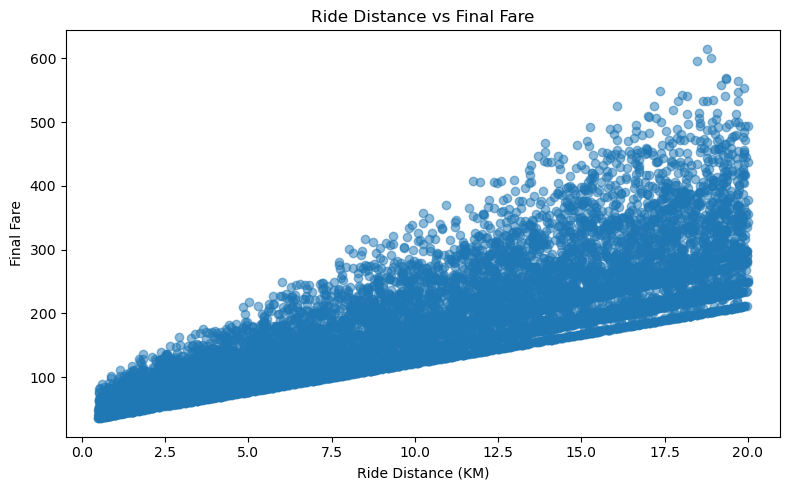

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Ride_Distance_KM"],
    df["Final_Fare"],
    alpha=0.5
)

plt.xlabel("Ride Distance (KM)")
plt.ylabel("Final Fare")
plt.title("Ride Distance vs Final Fare")
plt.tight_layout()
plt.show()

# Create a Matplotlib Correlation Matrix

A correlation matrix is displayed using Matplotlib only. Seaborn is intentionally not used.

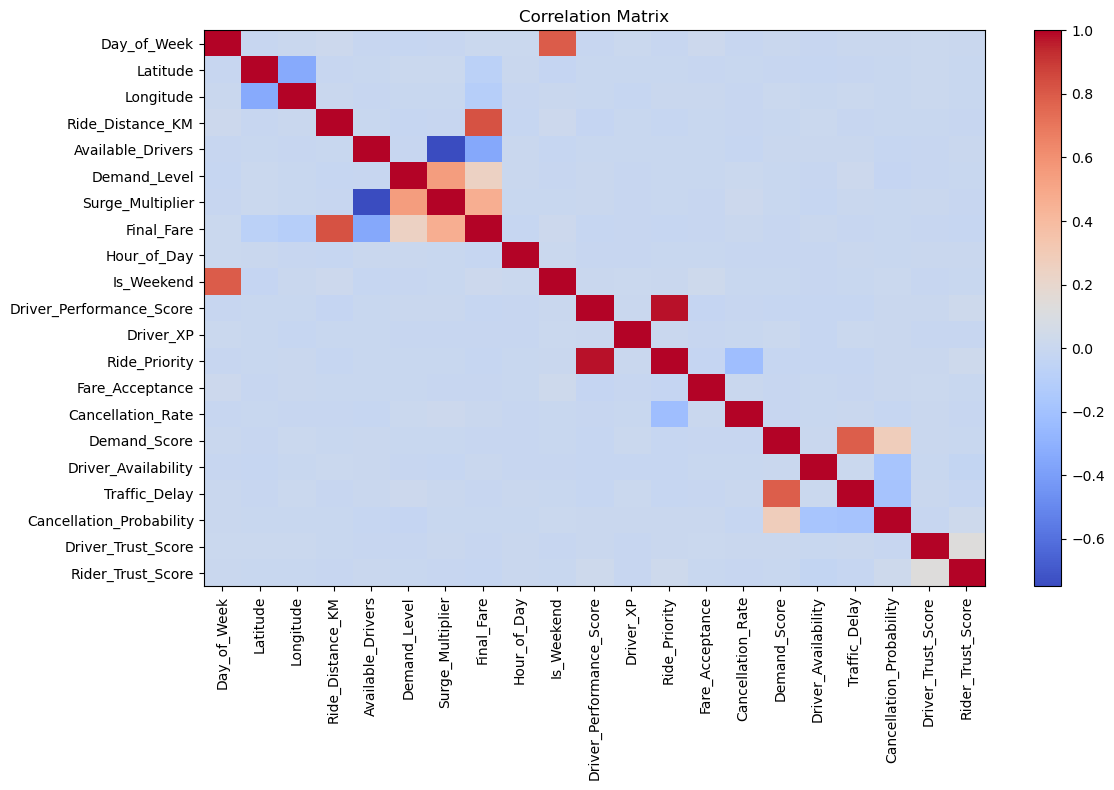

In [17]:
correlation = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 8))
plt.imshow(
    correlation,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Prepare the Dataset for Machine Learning

A separate copy is created for machine learning transformations so the original dataset remains unchanged.

The categorical variables used by the selected models are listed explicitly.

In [18]:
df_ml = df.copy()

print("Machine learning dataset shape:", df_ml.shape)

categorical_columns = [
    "City",
    "Day_of_Week",
    "Ride_Type",
    "Weather",
    "Event",
    "Payment_Type",
    "Demand_Level",
    "Ride_Priority",
    "Leaderboard_Rank"
]

print("Categorical columns selected for encoding:")
print(categorical_columns)

Machine learning dataset shape: (10000, 29)
Categorical columns selected for encoding:
['City', 'Day_of_Week', 'Ride_Type', 'Weather', 'Event', 'Payment_Type', 'Demand_Level', 'Ride_Priority', 'Leaderboard_Rank']


# Encode and Inspect Categorical Variables

Label encoding converts the selected categorical values into numerical values. The encoders are saved so the same mappings can be inspected later.

The transformed dataset is displayed after categorical encoding.

In [19]:
encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    df_ml[column] = encoder.fit_transform(df_ml[column].astype(str))
    encoders[column] = encoder

print("Categorical encoding completed.")
df_ml.head()

df_ml.head(10)

Categorical encoding completed.


,City,Date,Day_of_Week,Latitude,Longitude,Ride_Distance_KM,Ride_Type,Weather,Event,Payment_Type,Available_Drivers,Demand_Level,Surge_Multiplier,Final_Fare,Hour_of_Day,Is_Weekend,Driver_Performance_Score,Driver_XP,Ride_Priority,Fare_Acceptance,Cancellation_Rate,Time_of_Day,Demand_Score,Driver_Availability,Traffic_Delay,Cancellation_Probability,Driver_Trust_Score,Rider_Trust_Score,Leaderboard_Rank
0,3,06-08-2024,1,17.353253,78.466332,6.76,0,1,1,2,0.940635,153,1.00,92.84,5,0,97.53,554,1285,0.857885,0.07,Afternoon,80,46,15,0.2,100.0,100,2
1,4,26-09-2024,3,19.059839,72.858877,3.34,2,3,3,0,0.236479,6881,1.87,149.75,4,0,82.70,967,247,0.747193,0.07,Morning Peak,100,86,25,0.3,100.0,50,2
2,0,27-07-2024,5,12.976855,77.625306,8.86,1,2,1,2,0.916087,7208,1.00,153.18,23,1,95.71,806,1128,0.868523,0.08,Afternoon,100,32,15,0.3,100.0,100,2
3,4,23-03-2025,6,19.056439,72.863508,15.95,1,1,0,1,0.977525,8812,1.00,231.40,15,1,84.63,733,382,0.859991,0.07,Evening Peak,95,95,25,0.1,100.0,100,2
4,1,06-08-2024,1,13.110869,80.309381,19.50,2,0,4,0,0.843581,6707,1.00,244.50,12,0,80.59,677,160,0.981357,0.05,Evening Peak,65,58,10,0.1,0.0,0,2
5,2,17-10-2024,3,28.712901,77.079418,16.48,2,0,2,2,0.466766,7264,1.56,311.69,17,0,81.38,975,126,0.707646,0.08,Afternoon,80,30,15,0.2,100.0,5,2
6,2,21-10-2024,0,28.738914,77.089677,1.93,1,0,0,1,0.697425,3219,1.00,54.30,2,0,91.74,662,1000,0.890320,0.03,Night,80,53,15,0.1,100.0,100,2
7,2,16-02-2025,6,28.656649,77.134974,13.51,2,2,0,1,0.294377,9748,2.04,347.00,12,1,86.40,629,566,0.801697,0.05,Morning Peak,100,75,25,0.3,100.0,85,2
8,0,15-01-2025,2,12.957695,77.558570,11.78,2,3,4,2,0.579559,8582,1.51,288.62,4,0,96.08,795,1154,0.800077,0.08,Night,70,67,0,0.5,100.0,0,2
9,3,03-08-2024,5,17.381049,78.445229,7.33,1,0,0,1,0.768717,9238,1.29,126.38,19,1,85.06,686,592,0.841066,0.01,Night,80,46,15,0.2,100.0,100,2


# Define the Derived Travel Time

The dataset provides `Ride_Distance_KM` and `Traffic_Delay`, but it does not directly provide a travel-time target. Therefore, an estimated travel-time target is derived using an assumed average speed of 30 km/hour and the traffic delay.

In [20]:
AVERAGE_SPEED = 30  # kilometres per hour

df_ml["Base_Travel_Time"] = (
    df_ml["Ride_Distance_KM"] / AVERAGE_SPEED
) * 60

df_ml["Estimated_Travel_Time"] = (
    df_ml["Base_Travel_Time"] +
    df_ml["Traffic_Delay"]
)

df_ml[
    [
        "Ride_Distance_KM",
        "Traffic_Delay",
        "Base_Travel_Time",
        "Estimated_Travel_Time"
    ]
].head()

,Ride_Distance_KM,Traffic_Delay,Base_Travel_Time,Estimated_Travel_Time
0,6.76,15,13.52,28.52
1,3.34,25,6.68,31.68
2,8.86,15,17.72,32.72
3,15.95,25,31.90,56.90
4,19.50,10,39.00,49.00


# Visualize Estimated Travel Time

The relationship between ride distance and derived estimated travel time is visualized.

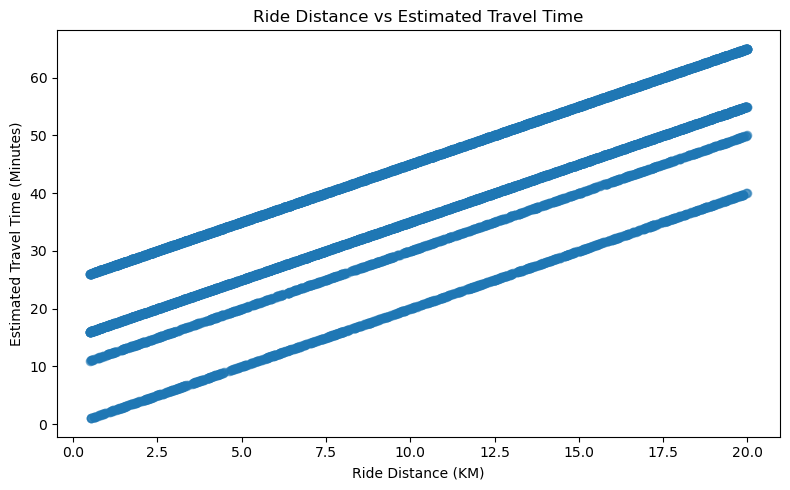

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_ml["Ride_Distance_KM"],
    df_ml["Estimated_Travel_Time"],
    alpha=0.5
)

plt.xlabel("Ride Distance (KM)")
plt.ylabel("Estimated Travel Time (Minutes)")
plt.title("Ride Distance vs Estimated Travel Time")
plt.tight_layout()
plt.show()

# Define Fare Prediction Features

The selected variables represent ride characteristics and factors associated with fare calculation.

In [44]:
fare_features = [
    "Ride_Distance_KM",
    "Demand_Level",
    "Surge_Multiplier",
    "Traffic_Delay",
    "Driver_Performance_Score",
    "Trust_Scores",
    "Hour_of_Day",
    "Is_Weekend"
]

fare_target = "Final_Fare"

print("Fare Features:")
print(fare_features)
print("Fare Target:", fare_target)

Fare Features:
['Ride_Distance_KM', 'Demand_Level', 'Surge_Multiplier', 'Traffic_Delay', 'Driver_Performance_Score', 'Trust_Scores', 'Hour_of_Day', 'Is_Weekend']
Fare Target: Final_Fare


# Prepare Fare Prediction Data

The input variables and final-fare target are separated.

In [45]:
X_fare = df_ml[fare_features]
y_fare = df_ml[fare_target]

print("Fare input shape:", X_fare.shape)
print("Fare target shape:", y_fare.shape)

KeyError: "['Trust_Scores'] not in index"

# Split Fare Data into Training and Testing Sets

The fare dataset is divided into training and testing sets using an 80:20 split.

In [28]:
X_train_fare, X_test_fare, y_train_fare, y_test_fare = train_test_split(
    X_fare,
    y_fare,
    test_size=0.20,
    random_state=42
)

print("Fare training records:", len(X_train_fare))
print("Fare testing records:", len(X_test_fare))

NameError: name 'X_fare' is not defined

# Train the Fare Linear Regression Model

Linear Regression is used to predict the final ride fare.

In [29]:
fare_model = LinearRegression()

fare_model.fit(
    X_train_fare,
    y_train_fare
)

print("Fare Linear Regression model trained successfully.")

NameError: name 'X_train_fare' is not defined

# Generate Fare Predictions

Predictions are generated for the unseen fare testing data.

In [30]:
fare_prediction = fare_model.predict(X_test_fare)

print("First 10 predicted fares:")
print(fare_prediction[:10])

NameError: name 'X_test_fare' is not defined

# Evaluate Fare Prediction

Fare prediction is evaluated using MAE, MSE, RMSE and R² Score.

In [31]:
fare_mae = mean_absolute_error(
    y_test_fare,
    fare_prediction
)

fare_mse = mean_squared_error(
    y_test_fare,
    fare_prediction
)

fare_rmse = np.sqrt(fare_mse)

fare_r2 = r2_score(
    y_test_fare,
    fare_prediction
)

print("===== FARE PREDICTION EVALUATION =====")
print("Mean Absolute Error       :", round(fare_mae, 2))
print("Mean Squared Error        :", round(fare_mse, 2))
print("Root Mean Squared Error   :", round(fare_rmse, 2))
print("R² Score                  :", round(fare_r2, 4))

NameError: name 'y_test_fare' is not defined

# Visualize Actual and Predicted Fare

Actual and predicted fare values are compared using a scatter plot. The dashed line represents perfect prediction.

In [32]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_fare,
    fare_prediction,
    alpha=0.5
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")

minimum = min(
    y_test_fare.min(),
    fare_prediction.min()
)

maximum = max(
    y_test_fare.max(),
    fare_prediction.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.tight_layout()
plt.show()

NameError: name 'y_test_fare' is not defined

<Figure size 800x600 with 0 Axes>

# Define Travel Time Prediction Features

The selected variables are used to predict the derived estimated travel-time target.

In [33]:
time_features = [
    "Ride_Distance_KM",
    "Traffic_Delay",
    "Demand_Level",
    "Hour_of_Day",
    "Is_Weekend"
]

time_target = "Estimated_Travel_Time"

print("Travel Time Features:")
print(time_features)
print("Travel Time Target:", time_target)

Travel Time Features:
['Ride_Distance_KM', 'Traffic_Delay', 'Demand_Level', 'Hour_of_Day', 'Is_Weekend']
Travel Time Target: Estimated_Travel_Time


# Prepare Travel Time Prediction Data

The travel-time input variables and derived target are separated.

In [34]:
X_time = df_ml[time_features]
y_time = df_ml[time_target]

print("Travel Time input shape:", X_time.shape)
print("Travel Time target shape:", y_time.shape)

Travel Time input shape: (10000, 5)
Travel Time target shape: (10000,)


# Split Travel Time Data into Training and Testing Sets

The travel-time data is divided into training and testing subsets using the same 80:20 approach.

In [35]:
X_train_time, X_test_time, y_train_time, y_test_time = train_test_split(
    X_time,
    y_time,
    test_size=0.20,
    random_state=42
)

print("Travel Time training records:", len(X_train_time))
print("Travel Time testing records:", len(X_test_time))

Travel Time training records: 8000
Travel Time testing records: 2000


# Train the Travel Time Decision Tree Model

A Decision Tree Regressor is used for estimated travel-time prediction. RandomForestRegressor is intentionally not used.

In [36]:
time_model = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
)

time_model.fit(
    X_train_time,
    y_train_time
)

print("Travel Time Decision Tree model trained successfully.")

Travel Time Decision Tree model trained successfully.


# Generate Travel Time Predictions

Predicted travel times are generated for the testing data.

In [37]:
time_prediction = time_model.predict(X_test_time)

print("First 10 predicted travel times:")
print(time_prediction[:10])

First 10 predicted travel times:
[52.9283871  27.73386364 24.05849462 18.93544554 36.77416667 59.35
 35.38472727 44.28533333 39.54583333 49.09775701]


# Evaluate Travel Time Prediction

The travel-time model is evaluated using MAE, MSE, RMSE and R² Score.

In [38]:
time_mae = mean_absolute_error(
    y_test_time,
    time_prediction
)

time_mse = mean_squared_error(
    y_test_time,
    time_prediction
)

time_rmse = np.sqrt(time_mse)

time_r2 = r2_score(
    y_test_time,
    time_prediction
)

print("===== TRAVEL TIME EVALUATION =====")
print("Mean Absolute Error       :", round(time_mae, 2))
print("Mean Squared Error        :", round(time_mse, 2))
print("Root Mean Squared Error   :", round(time_rmse, 2))
print("R² Score                  :", round(time_r2, 4))

===== TRAVEL TIME EVALUATION =====
Mean Absolute Error       : 0.2
Mean Squared Error        : 0.07
Root Mean Squared Error   : 0.27
R² Score                  : 0.9996


# Visualize Actual and Predicted Travel Time

Actual and predicted travel times are compared visually.

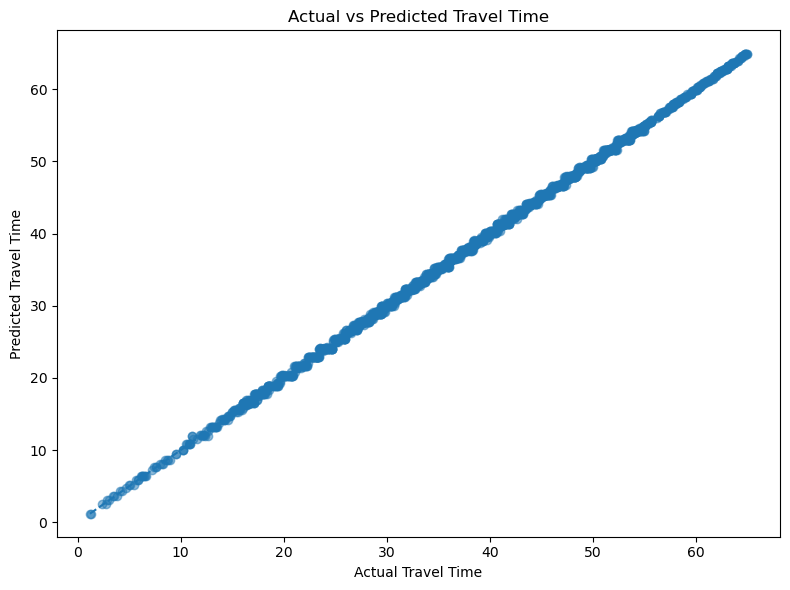

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_time,
    time_prediction,
    alpha=0.5
)

plt.xlabel("Actual Travel Time")
plt.ylabel("Predicted Travel Time")
plt.title("Actual vs Predicted Travel Time")

minimum = min(
    y_test_time.min(),
    time_prediction.min()
)

maximum = max(
    y_test_time.max(),
    time_prediction.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.tight_layout()
plt.show()

# Define the Delay Risk Target

The dataset contains `Traffic_Delay` but does not provide an original `Delay_Risk` target. A derived binary target is therefore created using the median traffic delay as the threshold.

In [40]:
delay_threshold = df_ml["Traffic_Delay"].median()

print(
    "Traffic Delay Threshold:",
    delay_threshold
)

df_ml["Delay_Risk"] = np.where(
    df_ml["Traffic_Delay"] > delay_threshold,
    1,
    0
)

print("\nDelay Risk Encoding:")
print("0 = Low Delay Risk")
print("1 = High Delay Risk")

Traffic Delay Threshold: 15.0

Delay Risk Encoding:
0 = Low Delay Risk
1 = High Delay Risk


# Analyze Delay Risk Distribution

The distribution of the derived delay-risk classes is displayed.

Delay Risk Counts:
Delay_Risk
0    6020
1    3980
Name: count, dtype: int64


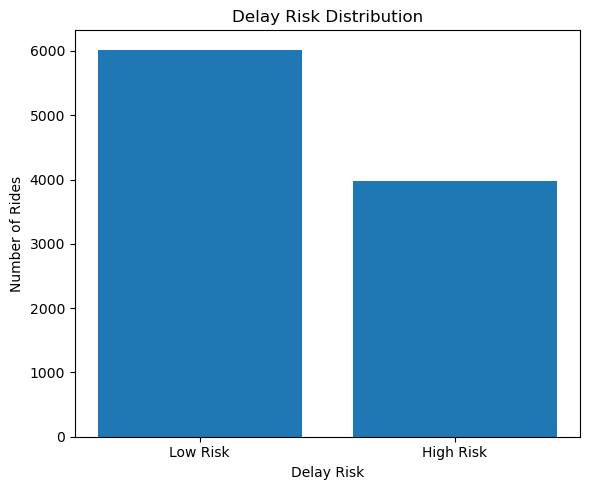

In [41]:
risk_counts = df_ml["Delay_Risk"].value_counts().sort_index()

print("Delay Risk Counts:")
print(risk_counts)

plt.figure(figsize=(6, 5))

plt.bar(
    ["Low Risk", "High Risk"],
    [
        risk_counts.get(0, 0),
        risk_counts.get(1, 0)
    ]
)

plt.xlabel("Delay Risk")
plt.ylabel("Number of Rides")
plt.title("Delay Risk Distribution")

plt.tight_layout()
plt.show()

# Define Delay Risk Features

Traffic_Delay is deliberately excluded from the model inputs because the delay-risk target was derived directly from Traffic_Delay. This prevents target leakage.

In [42]:
delay_features = [
    "Ride_Distance_KM",
    "Demand_Level",
    "Surge_Multiplier",
    "Hour_of_Day",
    "Is_Weekend",
    "Driver_Performance_Score",
    "Trust_Scores"
]

delay_target = "Delay_Risk"

print("Delay Risk Features:")
print(delay_features)
print("Delay Risk Target:", delay_target)

Delay Risk Features:
['Ride_Distance_KM', 'Demand_Level', 'Surge_Multiplier', 'Hour_of_Day', 'Is_Weekend', 'Driver_Performance_Score', 'Trust_Scores']
Delay Risk Target: Delay_Risk


# Prepare Delay Risk Prediction Data

The delay-risk features and target are separated.

In [43]:
X_delay = df_ml[delay_features]
y_delay = df_ml[delay_target]

print("Delay input shape:", X_delay.shape)
print("Delay target shape:", y_delay.shape)

KeyError: "['Trust_Scores'] not in index"

# Split Delay Risk Data into Training and Testing Sets

The classification data is split into training and testing sets while preserving the class distribution.

In [ ]:
X_train_delay, X_test_delay, y_train_delay, y_test_delay = train_test_split(
    X_delay,
    y_delay,
    test_size=0.20,
    random_state=42,
    stratify=y_delay
)

print("Delay training records:", len(X_train_delay))
print("Delay testing records:", len(X_test_delay))

# Train the Delay Risk Logistic Regression Model

Logistic Regression is used as the classification model for low and high delay risk.

In [ ]:
delay_model = LogisticRegression(
    max_iter=1000
)

delay_model.fit(
    X_train_delay,
    y_train_delay
)

print("Delay Risk Logistic Regression model trained successfully.")

# Generate Delay Risk Predictions

The trained classification model predicts the delay-risk class for the testing data.

In [ ]:
delay_prediction = delay_model.predict(X_test_delay)

print("First 20 predicted delay-risk classes:")
print(delay_prediction[:20])

# Evaluate Delay Risk Prediction

The delay-risk model is evaluated using Accuracy, Precision, Recall and F1 Score. ROC-AUC and ROC curves are intentionally not used.

In [ ]:
delay_accuracy = accuracy_score(
    y_test_delay,
    delay_prediction
)

delay_precision = precision_score(
    y_test_delay,
    delay_prediction,
    zero_division=0
)

delay_recall = recall_score(
    y_test_delay,
    delay_prediction,
    zero_division=0
)

delay_f1 = f1_score(
    y_test_delay,
    delay_prediction,
    zero_division=0
)

print("===== DELAY RISK EVALUATION =====")
print("Accuracy  :", round(delay_accuracy, 4))
print("Precision :", round(delay_precision, 4))
print("Recall    :", round(delay_recall, 4))
print("F1 Score  :", round(delay_f1, 4))

# Evaluate and Visualize the Delay Risk Confusion Matrix

The confusion matrix shows correct and incorrect predictions for low and high delay risk.

The confusion matrix is visualized with Matplotlib only.

In [ ]:
cm = confusion_matrix(
    y_test_delay,
    delay_prediction
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(
    cm,
    interpolation="nearest",
    cmap="Blues"
)

plt.title("Delay Risk Confusion Matrix")
plt.colorbar()

plt.xticks(
    [0, 1],
    ["Low Risk", "High Risk"]
)

plt.yticks(
    [0, 1],
    ["Low Risk", "High Risk"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

# Compare Regression Results

The regression results for fare and estimated travel time are summarized in a single table.

In [ ]:
regression_results = pd.DataFrame({
    "Task": [
        "Fare Prediction",
        "Travel Time Prediction"
    ],
    "Model": [
        "Linear Regression",
        "Decision Tree Regression"
    ],
    "MAE": [
        fare_mae,
        time_mae
    ],
    "MSE": [
        fare_mse,
        time_mse
    ],
    "RMSE": [
        fare_rmse,
        time_rmse
    ],
    "R2 Score": [
        fare_r2,
        time_r2
    ]
})

regression_results

# Summarize Classification Results

The delay-risk classification metrics are summarized in a table.

In [ ]:
classification_results = pd.DataFrame({
    "Task": [
        "Delay Risk Prediction"
    ],
    "Model": [
        "Logistic Regression"
    ],
    "Accuracy": [
        delay_accuracy
    ],
    "Precision": [
        delay_precision
    ],
    "Recall": [
        delay_recall
    ],
    "F1 Score": [
        delay_f1
    ]
})

classification_results

# Create the Final Smart Ride Prediction Function

This function accepts ride-related numerical inputs and returns the predicted fare, estimated travel time and delay risk. The categorical variables used during training are already encoded in the dataset, so the function expects their encoded numerical values.

In [ ]:
def predict_ride(
    distance,
    demand_level,
    surge_multiplier,
    traffic_delay,
    hour,
    is_weekend,
    driver_performance,
    trust_score
):
    # Fare prediction
    fare_input = pd.DataFrame({
        "Ride_Distance_KM": [distance],
        "Demand_Level": [demand_level],
        "Surge_Multiplier": [surge_multiplier],
        "Traffic_Delay": [traffic_delay],
        "Driver_Performance_Score": [driver_performance],
        "Trust_Scores": [trust_score],
        "Hour_of_Day": [hour],
        "Is_Weekend": [is_weekend]
    })

    predicted_fare = fare_model.predict(
        fare_input
    )[0]

    # Travel time prediction
    time_input = pd.DataFrame({
        "Ride_Distance_KM": [distance],
        "Traffic_Delay": [traffic_delay],
        "Demand_Level": [demand_level],
        "Hour_of_Day": [hour],
        "Is_Weekend": [is_weekend]
    })

    predicted_time = time_model.predict(
        time_input
    )[0]

    # Delay risk prediction
    delay_input = pd.DataFrame({
        "Ride_Distance_KM": [distance],
        "Demand_Level": [demand_level],
        "Surge_Multiplier": [surge_multiplier],
        "Hour_of_Day": [hour],
        "Is_Weekend": [is_weekend],
        "Driver_Performance_Score": [driver_performance],
        "Trust_Scores": [trust_score]
    })

    delay_result = delay_model.predict(
        delay_input
    )[0]

    if delay_result == 0:
        risk = "LOW"
    else:
        risk = "HIGH"

    print("\n======================================")
    print("       SMART RIDE PREDICTION")
    print("======================================")
    print(f"Estimated Fare        : ₹{predicted_fare:.2f}")
    print(f"Estimated Travel Time : {predicted_time:.2f} minutes")
    print(f"Delay Risk            : {risk}")
    print("======================================")

# Test the Final Smart Ride Prediction System

A sample ride is supplied to the final prediction function. The demand level, as well as other categorical variables that were label encoded during training, should be supplied using the encoded values produced by the notebook.

In [ ]:
# Example test input
# The encoded Demand_Level value below is an example.
# Check the encoder mapping before changing this value.

print("Demand Level Encoding:")
print(
    dict(
        zip(
            encoders["Demand_Level"].classes_,
            encoders["Demand_Level"].transform(
                encoders["Demand_Level"].classes_
            )
        )
    )
)

print("\nSample prediction:")

predict_ride(
    distance=10,
    demand_level=1,
    surge_multiplier=1.5,
    traffic_delay=10,
    hour=18,
    is_weekend=0,
    driver_performance=75,
    trust_score=80
)